# **Modelo de identifiacion de objetos en imagenes**


---



## **Modelo 1: Detección de Objetos Tradicional con DETR**



En esta primera fase, vamos a utilizar un modelo pre-entrenado llamado DETR (DEtection TRansformer) desarrollado por Facebook/Meta.

Este modelo pertenece a la categoría de detección de objetos clásica. Ha sido entrenado con el conjunto de datos COCO, lo que significa que tiene un "menú cerrado" y es capaz de reconocer 80 categorías diferentes de objetos comunes

Aqui la lista:

* **Personas**: person (persona).
* **Vehículos**: bicycle (bici), car (coche), motorcycle (moto), airplane (avión), bus, train, truck, boat.
* **Animales**: bird (pájaro), cat (gato), dog (perro), horse (caballo), sheep (oveja), cow (vaca), elephant, bear, zebra, giraffe.
* **Cosas de la calle**: traffic light (semáforo), fire hydrant (boca de incendios), stop sign (señal de stop), parking meter, bench (banco).
* **Cosas de casa/oficina**: backpack (mochila), umbrella (paraguas), handbag (bolso), tie (corbata), suitcase (maleta), tv, laptop, mouse, keyboard, cell phone, book, clock, vase.
* **Cocina y Comida**: bottle (botella), wine glass (copa), cup (taza), fork (tenedor), knife (cuchillo), spoon, bowl, banana, apple, sandwich, orange, broccoli, carrot, hot dog, pizza, donut, cake.
* **Muebles**: chair (silla), couch (sofá), potted plant (planta), bed (cama), dining table (mesa), toilet.


Para usarlo, aprovecharemos la herramienta pipeline de Hugging Face, que simplifica todo el proceso de descarga, preparación de la imagen y ejecución matemática en unas pocas líneas de código.

In [ ]:
# Instalamos las librerías necesarias para que el modelo DETR funcione en Colab
!pip install transformers torch pillow

In [ ]:
from transformers import pipeline

# 1. Descargamos y preparamos el modelo desde Hugging Face usando 'pipeline'
detector = pipeline(task="object-detection", model="facebook/detr-resnet-50")

# 2. Le indicamos la imagen con la ruta de la foto queramos
imagen = "botellaagua.jpg"

# 3. Le pedimos al modelo que mire la imagen
resultados = detector(imagen)

# 4. Imprimimos los resultados en pantalla
for objeto in resultados:
    print(f"Encontré: {objeto['label']}")
    print(f"Seguridad: {round(objeto['score'] * 100, 2)}%")
    print(f"Ubicación en la foto: {objeto['box']}")
    print("---")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2586: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  super()._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, whi

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                                         | Status     |  | 
----------------------------------------------------------------------------+------------+--+-
model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


preprocessor_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

The image processor of type `DetrImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Encontré: bottle
Seguridad: 99.7%
Ubicación en la foto: {'xmin': 1548, 'ymin': 441, 'xmax': 1921, 'ymax': 1526}
---


Como vemos el resultado nos dice el objeto que encontro ,el porcentaje de seguridad de lo que cree que es y la ubicacion del objeto en la foto



```
Encontré: bottle
Seguridad: 99.7%
Ubicación en la foto: {'xmin': 1548, 'ymin': 441, 'xmax': 1921, 'ymax': 1526}
```
Este resultado es muy util a la hora de saber que hace exactamente el modelo pero , para el usuario es muy poco visual , leemos eso y si es verdad hay una botella , pero, por que creer al modelo.

Asi que vamos a hacerlo mas visual para nosotros.


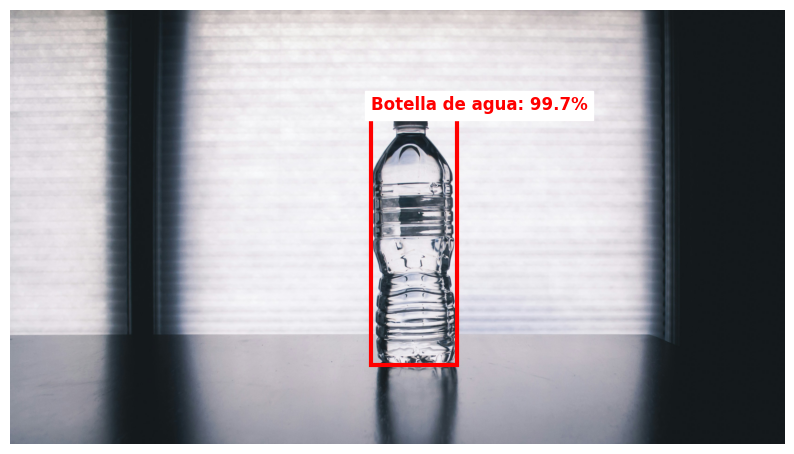

Total de botellas dibujadas: 1


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

imagen_real = Image.open(imagen)
# 1. Preparamos la imagen para mostrarla
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(imagen_real)

# 2. Recorremos los resultados y dibujamos una caja roja SOLO en la botella
botellas_encontradas = 0

for objeto in resultados:
    if objeto['label'] == 'bottle':
        botellas_encontradas += 1
        box = objeto['box']

        # Calculamos el ancho y alto de la caja
        xmin, ymin = box['xmin'], box['ymin']
        width = box['xmax'] - xmin
        height = box['ymax'] - ymin

        # Dibujamos el rectángulo rojo
        rect = patches.Rectangle((xmin, ymin), width, height, linewidth=3, edgecolor='red', facecolor='none')
        ax.add_patch(rect)

        # Le ponemos una etiqueta de texto encima
        texto = f"Botella de agua: {round(objeto['score'] * 100, 1)}%"
        plt.text(xmin, ymin - 10, texto, color='red', fontsize=12, weight='bold', backgroundcolor='white')

# 3. Quitamos los ejes y mostramos la foto final
plt.axis('off')
plt.show()

print(f"Total de botellas dibujadas: {botellas_encontradas}")

Este es un resultado muchisimo mas visual y mas transparente en cuanto a lo que hace el modelo.

Pero este modelo aunque muy util tiene un pequeño problema , puede que el objeto que deseamos encontrar no este entre los 80 que puede dectectar , por eso probaremos con el modelo **OWL-ViT**.


---

## **Modelo 2: Detección "Zero-Shot" con OWL-ViT (Google)**
A diferencia del modelo DETR clásico que acabamos de ver (el cual solo conoce 80 objetos predefinidos), ahora vamos a usar un modelo de Zero-Shot Object Detection llamado OWL-ViT, creado por Google.


"Zero-Shot" significa que el modelo puede detectar objetos que nunca ha visto durante su entrenamiento. En lugar de elegir de una lista cerrada, nosotros le pasamos una lista de texto con las palabras de lo que queremos buscar (como si se lo pidiéramos a ChatGPT). El modelo compara matemáticamente la imagen con nuestras palabras y busca coincidencias.


Esto es ideal para detectar objetos muy específicos, descripciones detalladas o cosas que no están en los datasets tradicionales, sin necesidad de reentrenar la IA.



Lo mas importante de este modelo es esta parte:


```
cosas_a_buscar = ["lion", "tiger", "rhino"]
resultados_zero = detector_zero(imagen_real, candidate_labels=cosas_a_buscar)
```


Crearemos una lista donde pondremos los objetos que queramos encontrar(en ingles funciona mucho mejor) y esta lista sera el valor de *candidate_labels* del modelo

Loading weights:   0%|          | 0/412 [00:00<?, ?it/s]

OwlViTForObjectDetection LOAD REPORT from: google/owlvit-base-patch32
Key                                         | Status     |  | 
--------------------------------------------+------------+--+-
owlvit.text_model.embeddings.position_ids   | UNEXPECTED |  | 
owlvit.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- ¡Análisis finalizado! Se han marcado 0 objetos. ---


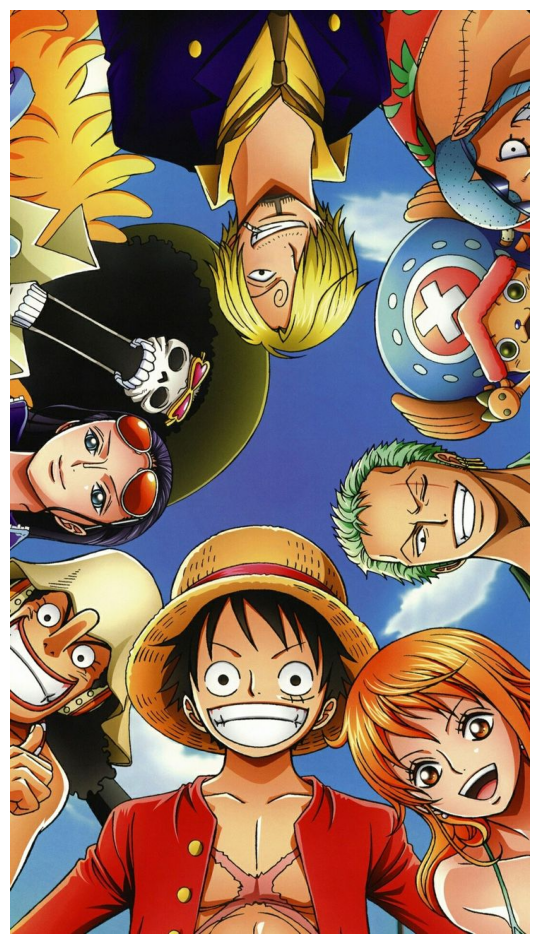

In [ ]:
from transformers import pipeline
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. Le indicamos la imagen con la ruta de la foto queramos
imagen_real = Image.open("animales2.jpg")


# 2. Cargamos el modelo OWL-ViT
# Usamos "google/owlvit-base-patch32"
detector_zero = pipeline(model="google/owlvit-base-patch32", task="zero-shot-object-detection")

# 3. AQUÍ DEFINIMOS LO QUE BUSCASMOS
cosas_a_buscar = ["Monkey", "Lion", "Tiger"]

# 4. Ejecutamos el modelo
resultados_zero = detector_zero(imagen_real, candidate_labels=cosas_a_buscar)

# --- VISUALIZACIÓN ---

fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(imagen_real)

objetos_dibujados = 0

# Aqui pondremos como de seguro tiene que estar el modelo como para que lo identifique como el objeto que busco
# Por ejemplo: 0.5 -> Tiene que tener un porcentaje mayor al 50% para que lo considere un objeto
umbral_seguridad = 0.1

for objeto in resultados_zero:
    if objeto['score'] > umbral_seguridad:
        objetos_dibujados += 1
        box = objeto['box']
        label = objeto['label']
        score = round(objeto['score'] * 100, 1)

        xmin, ymin = box['xmin'], box['ymin']
        width = box['xmax'] - xmin
        height = box['ymax'] - ymin

        rect = patches.Rectangle((xmin, ymin), width, height, linewidth=2, edgecolor='cyan', facecolor='none')
        ax.add_patch(rect)

        texto = f"{label}: {score}%"
        plt.text(xmin, ymin - 5, texto, color='black', fontsize=10, weight='bold', backgroundcolor='cyan')

plt.axis('off')
print(f"\n--- ¡Análisis finalizado! Se han marcado {objetos_dibujados} objetos. ---")
plt.show()

El resultado de este modelo depende mucho de el umbral de seguridad como vemos al fallado al detectar mas de un tigre , al detectar solo dos monos cuando hay cuatro.

Si cambiamos ese valor , encontrara mas monos pero tambien detectara animales que no son monos , leones donde no hay y mas tigres.

Por eso vamos a probar a entrenar nosotros mismos el modelo para que detecte de forma optima.

---

## **Modelo 3: Fine-Tuning y Detección en Tiempo Real con YOLOv8**
Los modelos anteriores son excelentes para pruebas rápidas o para buscar objetos genéricos, pero en la industria real necesitamos dos cosas: Velocidad y Personalización.

Para ello utilizamos YOLOv8 (You Only Look Once). Es la arquitectura estándar actual para visión por computadora porque es capaz de procesar vídeo en tiempo real y es increíblemente fácil de reentrenar (Fine-Tuning) con nuestros propios datos.

En esta sección, vamos a tomar un cerebro YOLO genérico (yolov8n - versión Nano, la más rápida) y le vamos a enseñar a detectar algo completamente nuevo mediante un dataset descargado de Roboflow ,en nuestro caso, personajes de One Piece / Mugiwaras.

Nota importante para Colab: Antes de ejecutar el entrenamiento, tendremos que tener activada la GPU yendo al menú superior:

Entorno de ejecución > Cambiar tipo de entorno de ejecución > Acelerador de hardware: T4 GPU.

In [ ]:
# 1. Instalamos la librería oficial de YOLO (Ultralytics) y Roboflow
!pip install -q ultralytics roboflow

from IPython import display
display.clear_output()

import ultralytics
ultralytics.checks() # Esto nos confirmará si la GPU está activa correctamente

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 44.6/112.6 GB disk)


### **Descarga del Dataset y Entrenamiento**

En lugar de etiquetar imágenes a mano, descargaremos un dataset ya preparado desde Roboflow Universe. El siguiente bloque de código conecta con Roboflow, descarga las imágenes (con sus "cajas" ya dibujadas) y las prepara en el formato exacto que YOLO necesita.

Una vez descargado, iniciaremos el entrenamiento. Le diremos a la IA que repase nuestras fotos varias veces (epochs) para que aprenda a reconocer los patrones visuales de nuestros objetos.


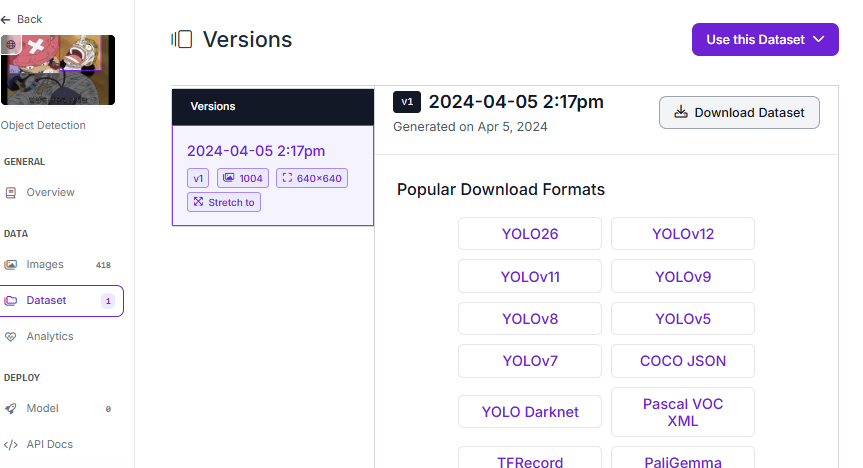

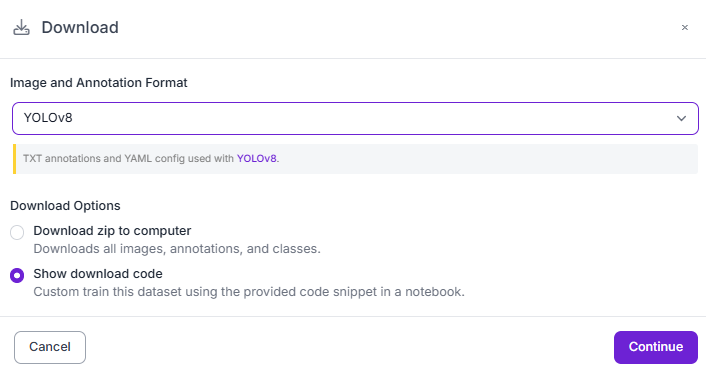



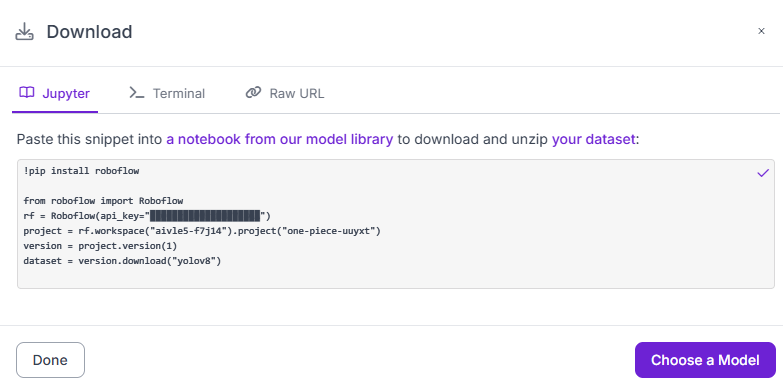

In [ ]:
from roboflow import Roboflow
from ultralytics import YOLO

# 1. Conexión con Roboflow (Reemplaza esto con tu código de Roboflow Universe)
# Ejemplo de cómo se ve el código que te da la plataforma:
rf = Roboflow(api_key="hcQjug5LDWstHNaVc8GA")
project = rf.workspace("aivle5-f7j14").project("one-piece-uuyxt")
version = project.version(1)
dataset = version.download("yolov8")

# 2. Cargamos el modelo base
model = YOLO('yolov8n.pt')

# 3. COMENZAMOS EL ENTRENAMIENTO
# data: apunta al archivo de configuración que acaba de descargar Roboflow
# epochs: número de veces que repasará el dataset (25-50 suele ser un buen inicio)
# imgsz: tamaño al que redimensionará las imágenes para ir más rápido
print("Iniciando el entrenamiento... Esto puede tardar unos minutos.")
model.train(data=f"{dataset.location}/data.yaml", epochs=25, imgsz=640)



loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to ONE-PIECE-1 in yolov8:: 100%|██████████| 2017/2017 [00:00<00:00, 2832.75it/s]


Iniciando el entrenamiento... Esto puede tardar unos minutos.
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ONE-PIECE-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=Fals

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a71fe90f0e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0470

## Ahora procederemos a la parte final , la prediccion.

Primero guardaremos nuestro modelo entrenado para no tener que volver a entrenarlo , esto lo haremos descargando un archivo llamado *best.pt*.

Ese archivo es nuestra Inteligencia Artificial. Contiene todas las matemáticas y todo lo que ha aprendido en estos minutos. Con ese archivo descargado , mañana podriamos hacer una aplicación web o una app para el móvil que detecte personajes de One Piece usando la cámara, sin tener que volver a entrenar nunca más , pero eso ya es para otro trabajo :) .

In [ ]:
import cv2
import matplotlib.pyplot as plt
from google.colab import files
from ultralytics import YOLO

print("¡Entrenamiento finalizado!")

# YOLO guarda siempre el mejor resultado de tu entrenamiento en un archivo llamado 'best.pt'
ruta_mejor_modelo = "runs/detect/train/weights/best.pt"

print("Descargando tu modelo (best.pt) a tu ordenador...")
# Esto abrirá una descarga en tu navegador. ¡Guárdalo bien, es tu IA!
files.download(ruta_mejor_modelo)



¡Entrenamiento finalizado!
Descargando tu modelo (best.pt) a tu ordenador...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Y por fin podremos realizar la prediccion que queremos

Haciendo la predicción...

image 1/1 /content/mugis4.jpg: 448x640 1 Chyopa, 1 Franky, 1 Luffy, 1 Nami, 1 NicoRobin, 1 Sangdi, 1 Usopp, 1 Zoro, 39.8ms
Speed: 2.2ms preprocess, 39.8ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)


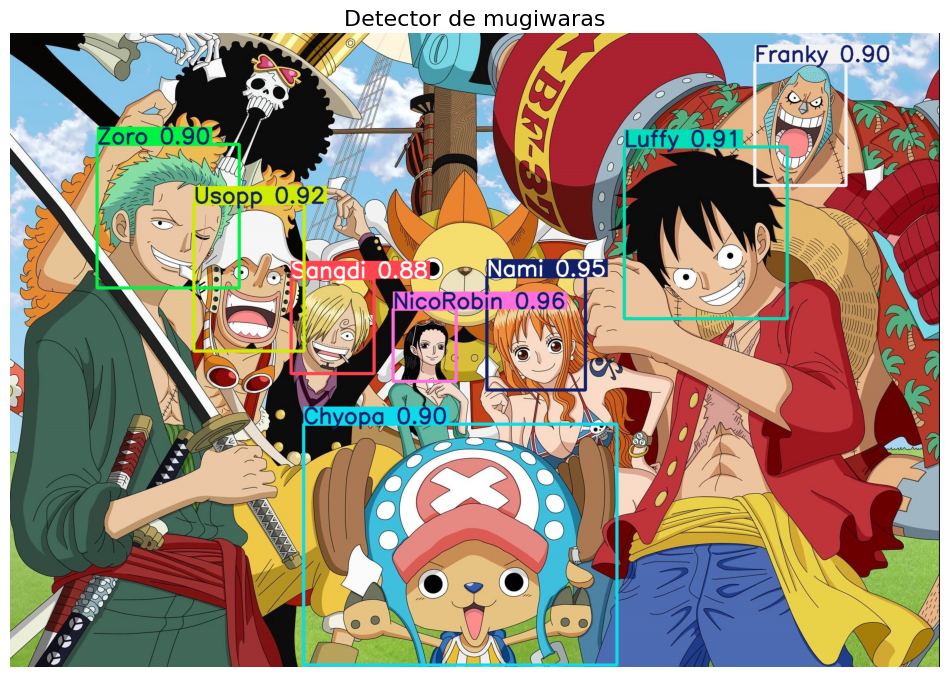

In [ ]:
nombre_foto_test = "mugis4.jpg"

print("Haciendo la predicción...")
# Cargamos NUESTRO modelo (best.pt), no el genérico
mi_modelo = YOLO(ruta_mejor_modelo)
resultados = mi_modelo.predict(source=nombre_foto_test, conf=0.5)

# Extraemos y mostramos la imagen
imagen_resultado = resultados[0].plot()
imagen_resultado_rgb = cv2.cvtColor(imagen_resultado, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 12))
plt.imshow(imagen_resultado_rgb)
plt.axis('off')
plt.title("Detector de mugiwaras", fontsize=16)
plt.show()

## **Conclusion**:
---
**1. El Especialista Clásico (Modelo DETR)**

**El concepto**: Usar un modelo pre-entrenado estándar.

**Lo que aprendimos**: Vimos lo increíblemente fácil que es usar la librería transformers de Hugging Face. Con unas pocas líneas de código, tuvimos acceso a un modelo capaz de detectar 80 objetos comunes (dataset COCO) con alta precisión.

---
**2. El Explorador Flexible (Modelo Zero-Shot OWL-ViT)**
**El concepto**: Detección basada en texto (sin entrenamiento previo).

**Lo que aprendimos**: Experimentamos la magia de los modelos multimodales. Comprobamos que podemos pedirle a la IA que busque objetos que nunca ha visto antes, simplemente describiéndolos con palabras.

---
**3. El Atleta a Medida (Modelo YOLOv8 Custom)**

**El concepto**: Fine-Tuning (Re-entrenamiento personalizado).

**Lo que aprendimos**: El flujo de trabajo real de la industria. Tomamos un modelo ultrarrápido pero genérico, fuimos a Roboflow a por nuestros propios datos etiquetados (Mugiwaras/One Piece), y forzamos a la tarjeta gráfica a aprender esos nuevos patrones. Exportamos nuestro propio "cerebro" (best.pt).

---
**Reflexión Final**

La Inteligencia Artificial ya no es magia oscura reservada para grandes corporaciones. Plataformas como Hugging Face, Google Colab y Ultralytics han facilitado el acceso. El límite ahora no es la potencia de cálculo, sino nuestra capacidad para conseguir buenos datos y hacer las preguntas correctas.